In [1]:
!pip install ~/fwiVis/utility_functions/
! pip install plotnine

Processing /home/jovyan/fwiVis/utility_functions
  Preparing metadata (setup.py) ... done
  Created wheel for fwiVis: filename=fwiVis-0.1-py3-none-any.whl size=17891 sha256=86598d3bb22f7bda8b2f8f3639371df964b4c10125fca67c0ca2e2426494f2c6
  Stored in directory: /tmp/pip-ephem-wheel-cache-mka83w5l/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Using cached plotnine-0.14.5-py3-none-any.whl.metadata (9.3 kB)
  Using cached mizani-0.13.1-py3-none-any.whl.metadata (4.7 kB)
Using cached plotnine-0.14.5-py3-none-any.whl (1.3 MB)
Using cached mizani-0.13.1-py3-none-any.whl (127 kB)


In [2]:
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
#import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain

from datetime import date
from bs4 import BeautifulSoup
import requests
import os
import plotnine
import xarray as xr

In [7]:
import fwiVis.fwiVis as fv

#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_only/April_1_unmerged_fires_with_FWI.csv"
#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Final_dataset_as_of_20240209.csv"
#fire3 = fv.prep_fire_files(path)

path = os.path.abspath("data/Quebec_v3_full_data_perimeters20241112.csv")
fire3 = fv.prep_fire_files(path)

#ciffc = pd.read_csv("/projects/old_shared/fire_weather_vis/Lightning_analysis/CIFFC_data/ciffc_all_canada.csv")
ciffc = pd.read_csv(os.path.abspath("contextual_data/CIFFC_data/ciffc_all_canada.csv"))
ciffc = ciffc[ciffc.field_agency_code == "qc"]

ciffc = gpd.GeoDataFrame(ciffc, geometry= gpd.points_from_xy(ciffc.field_longitude, ciffc.field_latitude), crs = "4326")
ciffc = ciffc.to_crs("3571")

ciffc["geometry_point"] = ciffc.geometry

In [8]:
fire3 = fire3.sort_values(by = ["fireID", "t"])
fire3 = fire3[~fire3.FWI.isna()]
#fire3.farea = fire3.farea.astype("int64")
fire3 = fire3.sjoin(ciffc)
fire3["farea_diff"] = fire3.groupby("fireID").farea.diff()

row_mask = (~fire3.fireID.str.contains("_"))

#fire3[row_mask].hvplot.scatter(x='FWI', y='farea_diff', hover_cols=['fireID', 't'])
#fire3[row_mask].plot.scatter(x='FWI', y='farea_diff')

In [9]:
supression = fire3.groupby("fireID").field_response_type.unique().reset_index()
supression

supression["len"] = supression.field_response_type.apply(len)

multi_suppress_ids = supression[supression.len> 1].fireID

supression[supression.len> 1]
fire_ids_not_unique_supression = supression[supression.len> 1].fireID

In [10]:
### Function that takes a point and looks for the multi polygons that intersect with that point. 
#It then assignes just the polygon portion of the multipolygon with the point's ID. 
# At the end, I want to put in an ID where there are two supression stratagies, and I want to get two IDs out, one per supression stratagy: subset to just the portion where there is one supression strategy.  
# I have found one fire so far (1082) where this wont work, because at least some probable fire that could/should be tied to one surpession strategy doesn't overlap with the point, even after the reported time, and by the time out polygon overlapped with the point it was already merged with anouther one. So boo. 

import shapely
import shapely.geometry as gmt
from shapely.geometry import MultiPolygon, Point, Polygon

def split_multipolygon(multipolygon, point):
    """Splits a MultiPolygon into separate polygons based on intersection with a point.

    Args:
        multipolygon (MultiPolygon): The MultiPolygon to split.
        point (Point): The point used to determine intersection.

    Returns:
        list: A list of individual polygons.
    """

    polygons = []
    for polygon in multipolygon:
        if polygon.intersects(point):
            polygons.append(polygon)
    return polygons


def exactly_one_true(lst):
    """Checks if exactly one element in the list is True."""
    return sum(lst) == 1

def sep_supression(fid, df1,  meter_crs = 3571, point_crs = 4326): #df2,
    print("Assuming df1 is in  crs 4326, and df2 is in a metered crs (35")
    df = df1[df1.fireID == fid]
    #df2 = df2[df2.fireID == fid]
    #df = df[30:40]
    # df = df.to_crs(meter_crs)
    # df.geometry = df.geometry.buffer(500) ## 200 meeters
    # df = df.to_crs(point_crs)
    ciffc_resp = df.field_response_type.unique()
    resp_l = []
    #for r in ciffc_resp:
    just_intersect = []
    #unique_points = df[["field_latitude", "field_longitude", "field_response_type", "field_agency_fire_id"]].drop_duplicates().reset_index(drop = True) # (df.field_response_type == r)
    #unique_points = gpd.GeoDataFrame(unique_points, geometry= gpd.points_from_xy(unique_points.field_longitude, unique_points.field_latitude,  crs = 4326))

    unique_points = df[["geometry_point", "field_response_type", "field_agency_fire_id"]].drop_duplicates().reset_index(drop = True)
    unique_points = gpd.GeoDataFrame(unique_points, geometry= unique_points.geometry_point,  crs = 3571)
    #return(unique_points)
    #points = [Point(lon, lat) for lon, lat in zip(unique_points.field_longitude, unique_points.field_latitude)]
    points = unique_points.geometry_point
    #print(len(points))
    #return(points)
    
    for index, row in df.iterrows(): # [df.field_response_type == r]
    #if isinstance(row['geometry'], MultiPolygon):
        #print("This is a multipolygon")
       #split_polygons = split_multipolygon(row['geometry'], intersection_point)
        ## Double check that only 1 point intersects with polygon. 
        if(isinstance(row['geometry'], Polygon)):
            row['geometry'] = gmt.MultiPolygon([row['geometry']])
        for polygon in row['geometry'].geoms:
            #print(shapely.intersects(points, polygon))
            unique_points["Does_it_intersect"] = np.nan
            intersecting_points = []
            for point in points:
                intersecting_points.append(polygon.intersects(point))
                    
            unique_points["Does_it_intersect"] = intersecting_points
            up_group = unique_points.groupby("field_response_type").Does_it_intersect.unique().reset_index()
            #return(up_group)

            only_one_type_of_supression_intersects = (sum(up_group.Does_it_intersect.explode().values) == 1)
            #intersecting_points = [point for point in points if polygon.intersects(point)]
            #print(intersecting_points)

            #if len(intersecting_points) == 1:  # Exactly one point intersects
            if only_one_type_of_supression_intersects: ### Only one catagory intersects with this polygon
                #print(only_one_type_of_supression_intersects)
                #return(up_group)
                new_row = row.copy()
                new_row["geometry"] = polygon
                new_row["farea"] = (polygon.area / (1000 * 1000))
                new_row["fperim"] = np.nan
                new_row["meanFRP"] = np.nan
                
                
                
                # try:
                    #new_row["fireID"] = str(fid) + "." +str(up_group[up_group.Does_it_intersect.sum()].field_response_type.iloc[0])# tmp2[tmp2.source.explode()].degree.iloc[0]
                    #new_row["fireID"] = str(fid) + "." +str(up_group[up_group.Does_it_intersect.apply(any)].field_response_type.iloc[0]) + "." + str(*unique_points[unique_points.Does_it_intersect == True].field_agency_fire_id.unique())
                sup = str(up_group[up_group.Does_it_intersect.apply(any)].field_response_type.iloc[0])
                new_row["fireID"] = str(fid) + "." + sup +"." +  ".".join(unique_points[unique_points.Does_it_intersect == True].field_agency_fire_id.astype("str"))
                new_row["field_response_type"] = sup
                    
                # except:
                #     return(unique_points)
                # #     return(up_group)
                    
                just_intersect.append(new_row)
                # fig, ax = plt.subplots(figsize=(8, 6))
                # #print(type(new_row))
                # #new_row.plot(color = "green")
                # plt.plot(*new_row["geometry"].exterior.xy, color = "green")
                # for point in points:
                #     ax.plot(point.x, point.y, 'ro', label="Point")  # 'ro' for red points
                
                #     # Adjust the plot
                #     ax.set_title("Geometry and Points")
                #     ax.set_xlabel("Longitude")
                #     ax.set_ylabel("Latitude")
                #     plt.grid(True)
                    
                #     # Show the plot
                #     plt.show()
                #plt.plot(*new_row["geometry"].exterior.xy, color = "green")
                #plt.plot(*unique_points["geometry"].exterior.xy, color = "red")
                #unique_points.plot(color = "red")
                #plt.plot(unique_points.field_longitude, unique_points.field_latitude,  color = "red")
                #plt.show()
            else:
                new_row = row.copy()
                new_row["geometry"] = polygon
                # fig, ax = plt.subplots(figsize=(8, 6))
                # plt.plot(*new_row["geometry"].exterior.xy, color = "yellow")
                # for point in points:
                #     ax.plot(point.x, point.y, 'ro', label="Point")  # 'ro' for red points
                
                #     # Adjust the plot
                #     ax.set_title("Geometry and Points")
                #     ax.set_xlabel("Longitude")
                #     ax.set_ylabel("Latitude")
                #     plt.grid(True)
                    
                #     # Show the plot
                #     plt.show()
                #plt.plot(*new_row["geometry"].exterior.xy, color = "yellow")
                #plt.plot(unique_points.field_longitude, unique_points.field_latitude,  color = "red")
                #plt.plot(*unique_points["geometry"].exterior.xy, color = "red")
                #unique_points.plot(color = "red")
                #plt.show()
                #print("skipping")
                #just_intersect.append(None)
    # else:
    #     just_intersect.append(row)
    just_intersect_df = gpd.GeoDataFrame(just_intersect)
    just_intersect_df = gpd.GeoDataFrame(just_intersect_df, geometry = just_intersect_df.geometry, crs = 3571)
    #just_intersect_df = just_intersect_df[just_intersect_df.field_response_type == sup] # Dropping false lable
    just_intersect_df = just_intersect_df.drop_duplicates()
    # if(len(just_intersect_df) > 0):
    #     #print(just_intersect)
    #     just_intersect_df.fireID = just_intersect_df.fireID.astype("str") + "." + r
    #     #print(just_intersect_df)
    #     resp_l.append(just_intersect_df)
    # else:
    #     print(f"{fid} had no independant multi-polygons to split")
#full_df = pd.concat(resp_l, axis=0)
    return(just_intersect_df)
    

def check_that_continious_record(df):
    min_t = df.t.min()
    max_t = df.t.max()
    #dates = pd.date_range(start= min_t, end=  max_t).to_pydatetime().tolist()
    dates = pd.date_range(start= min_t, end=  max_t).strftime('%Y-%m-%d 12:00:00').tolist()
    len_df = len(df.t.unique())
    #print(df.t.unique())
    len_seq = len(dates)
    #print(dates)
    if(len_df != len_seq):
        print(f"FireID {df.fireID.unique()} is not a continious sequence.")
        return(False)
    d_list = []
    for d in dates:
        some_dates = df[df.t == d]
        d_list.append(len(some_dates) > 0)
    return(any(d_list))
        

    

In [11]:
### remake IDs with duel supression status 


skip_list = ["1082", 
            "1324"] ### has more than one supression, but seems like the reported point doesn't overlap with an indepandant multipolygon. 

duel_sup =  [item for item in fire_ids_not_unique_supression if item not in skip_list]
dfs = []
for s in duel_sup:
    print(s)
    tmp = sep_supression(str(s), fire3)
    dfs.append(tmp)
foo = pd.concat(dfs)

1088
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35
226
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35
2545
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35
2647
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35
2649
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35


In [12]:
#### Check that there is a continious t 


bools = foo.groupby("fireID").apply(check_that_continious_record)
print(f"Are all the fires continuios records???: {all(bools)}")

if(all(bools)):
    fire3 = fire3[~fire3.fireID.isin(fire_ids_not_unique_supression)]
    foo = foo.to_crs(fire3.crs)
    fire3 = pd.concat([fire3, foo], ignore_index=True)

Are all the fires continuios records???: True


/tmp/ipykernel_636/3505659453.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [13]:
fire3 = fire3.sort_values(by = ["fireID", "t"])
fire3 = fire3[~fire3.FWI.isna()]

In [15]:
fire3["FWI_diff"] = fire3.groupby("fireID").FWI.diff()
fire3["farea_diff"] = fire3.groupby("fireID").farea.diff()
fire3["FWI_rolling"] = fire3.groupby("fireID").FWI.rolling(3).max().reset_index(drop = True)

def normalize_fwi(df, col = "FWI"):
    #print(df[col].mean())
    df[col+"_norm"] = df[col]/df[col].mean()
    return(df)

fire3 = fire3.groupby("fireID").apply(normalize_fwi).reset_index(drop = True)


#fire3[row_mask].hvplot.scatter(x='FWI_diff', y='farea_diff', hover_cols=['fireID', 't'])
#fire3[row_mask].plot.scatter(x='FWI', y='farea_diff')

/tmp/ipykernel_636/3646717682.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


/tmp/ipykernel_636/1318316756.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/srv/conda/envs/notebook/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 161 rows containing missing values.


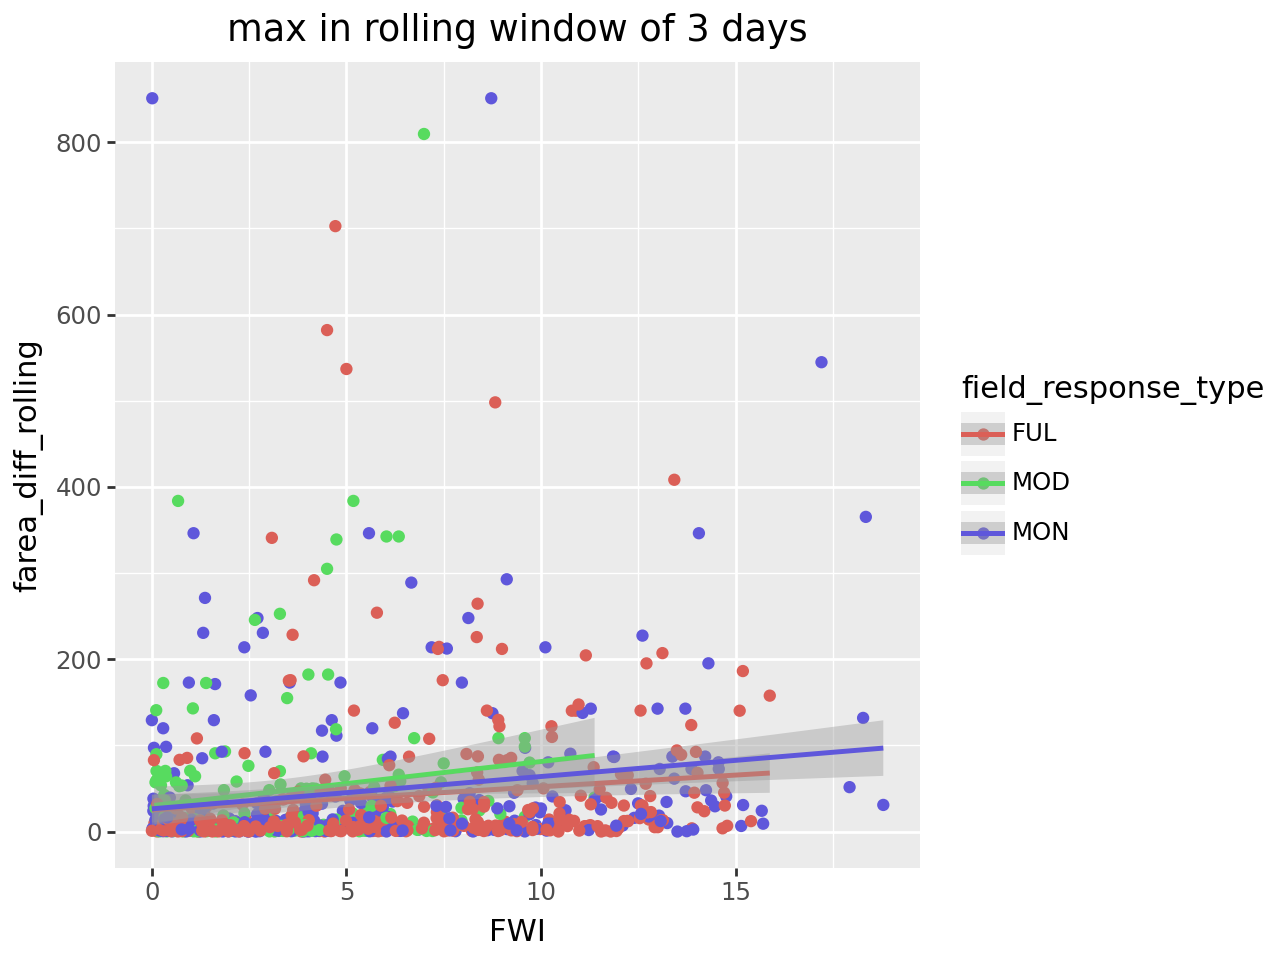

<ggplot: (640 x 480)>


/srv/conda/envs/notebook/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 161 rows containing missing values.


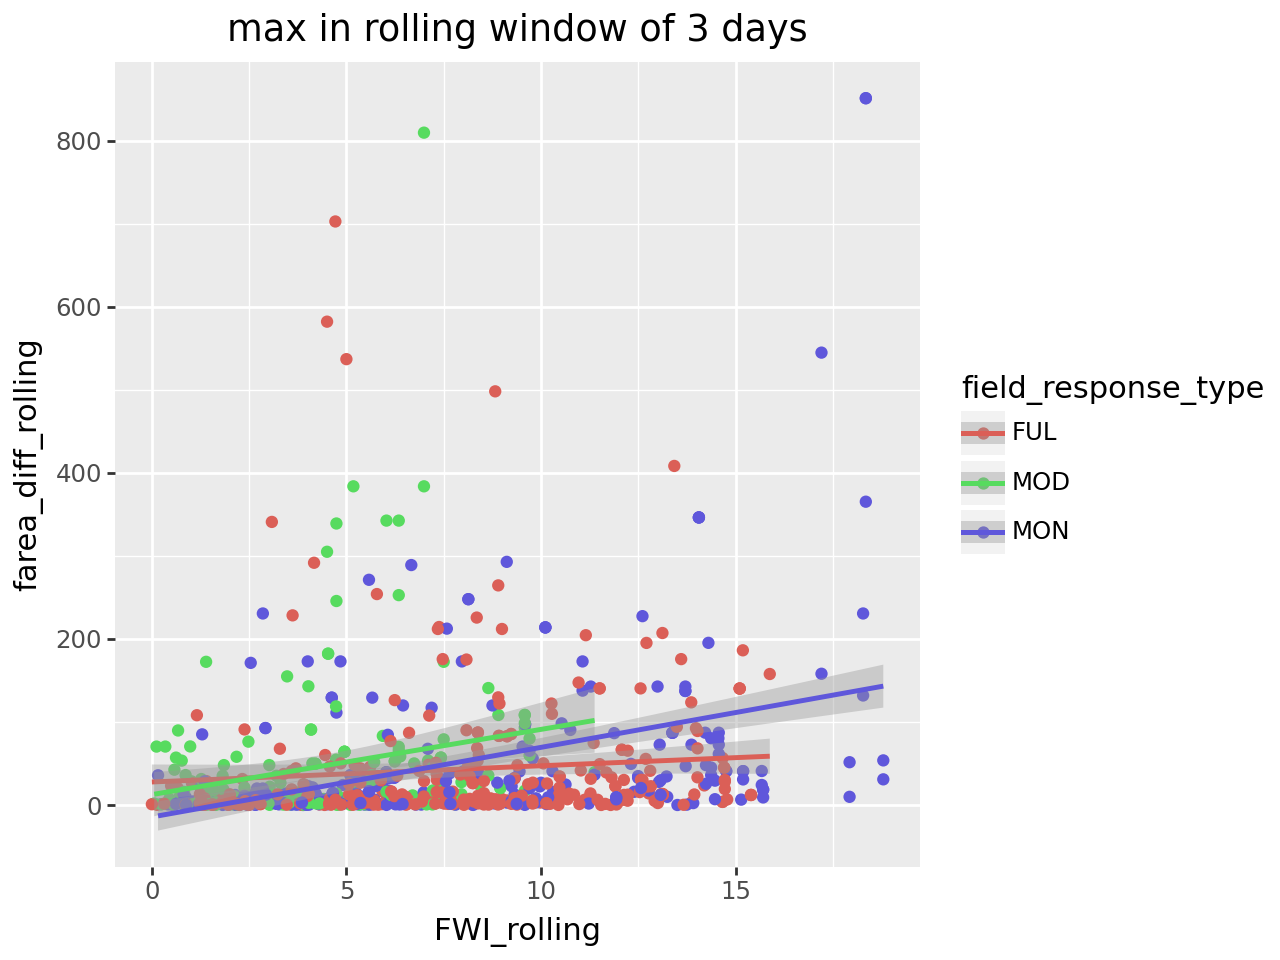

<ggplot: (640 x 480)>


/srv/conda/envs/notebook/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 161 rows containing missing values.


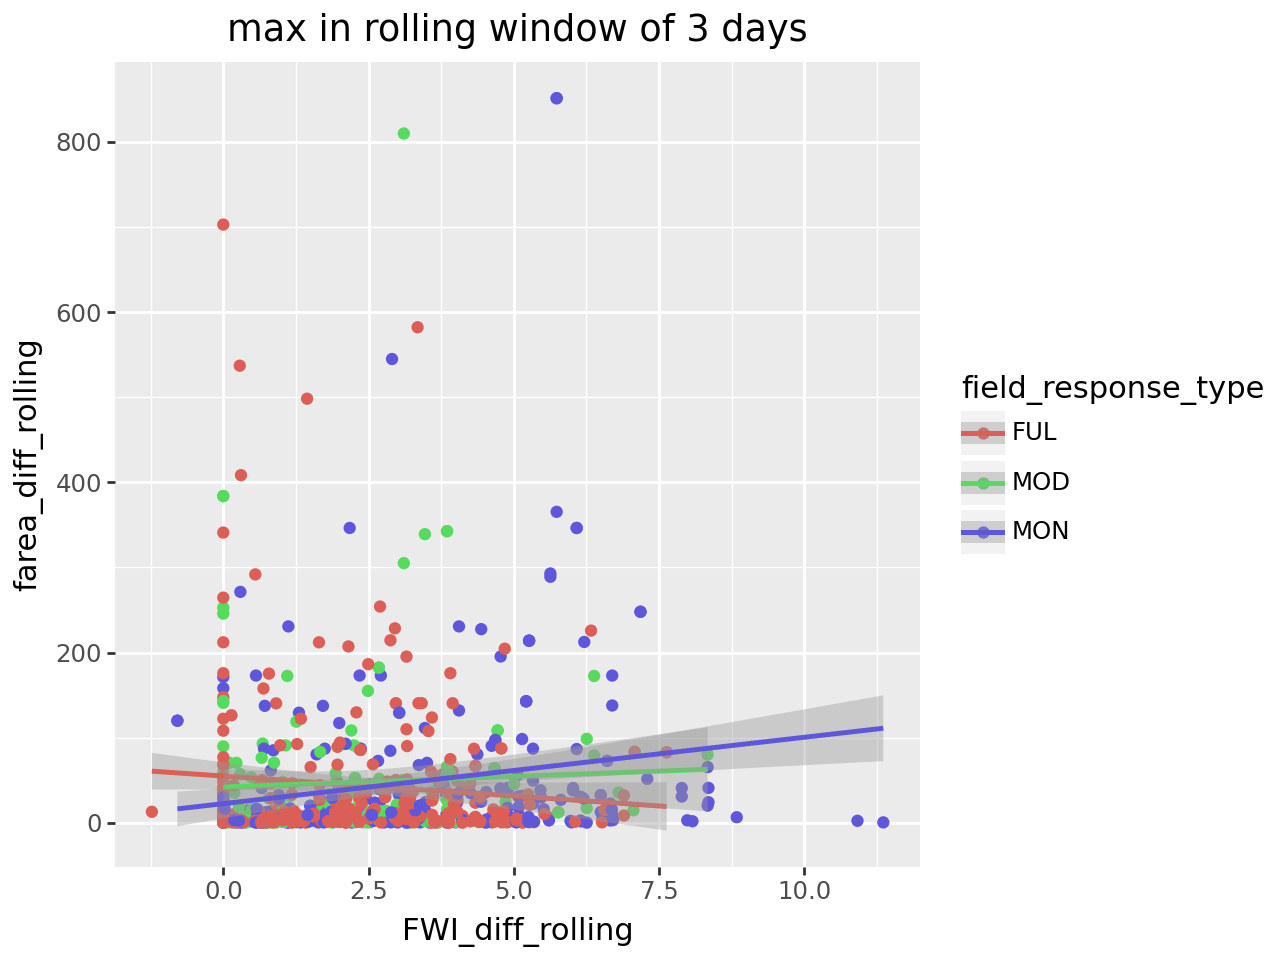

<ggplot: (640 x 480)>


/srv/conda/envs/notebook/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 161 rows containing missing values.


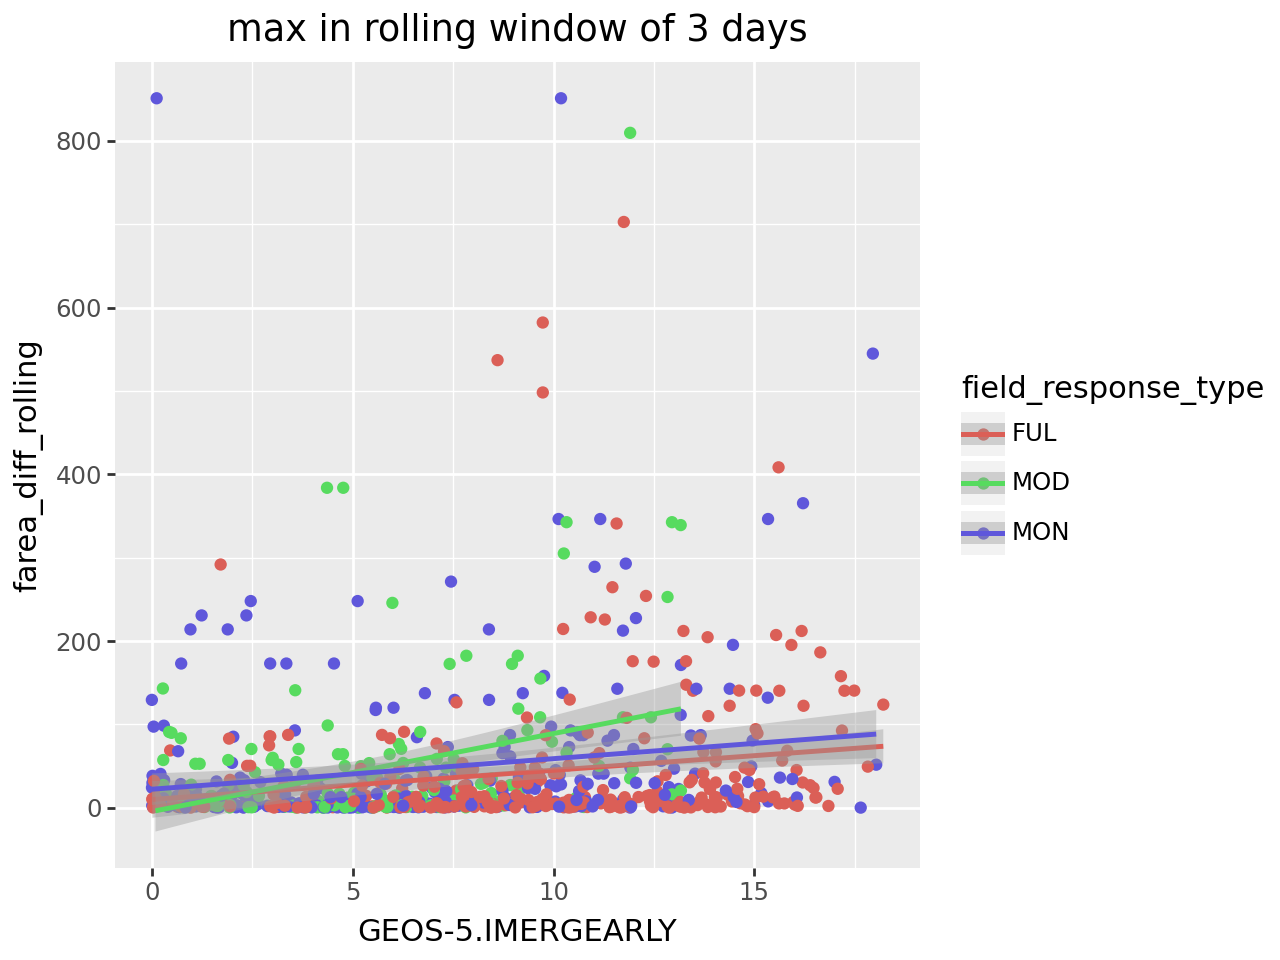

<ggplot: (640 x 480)>


/srv/conda/envs/notebook/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 161 rows containing missing values.


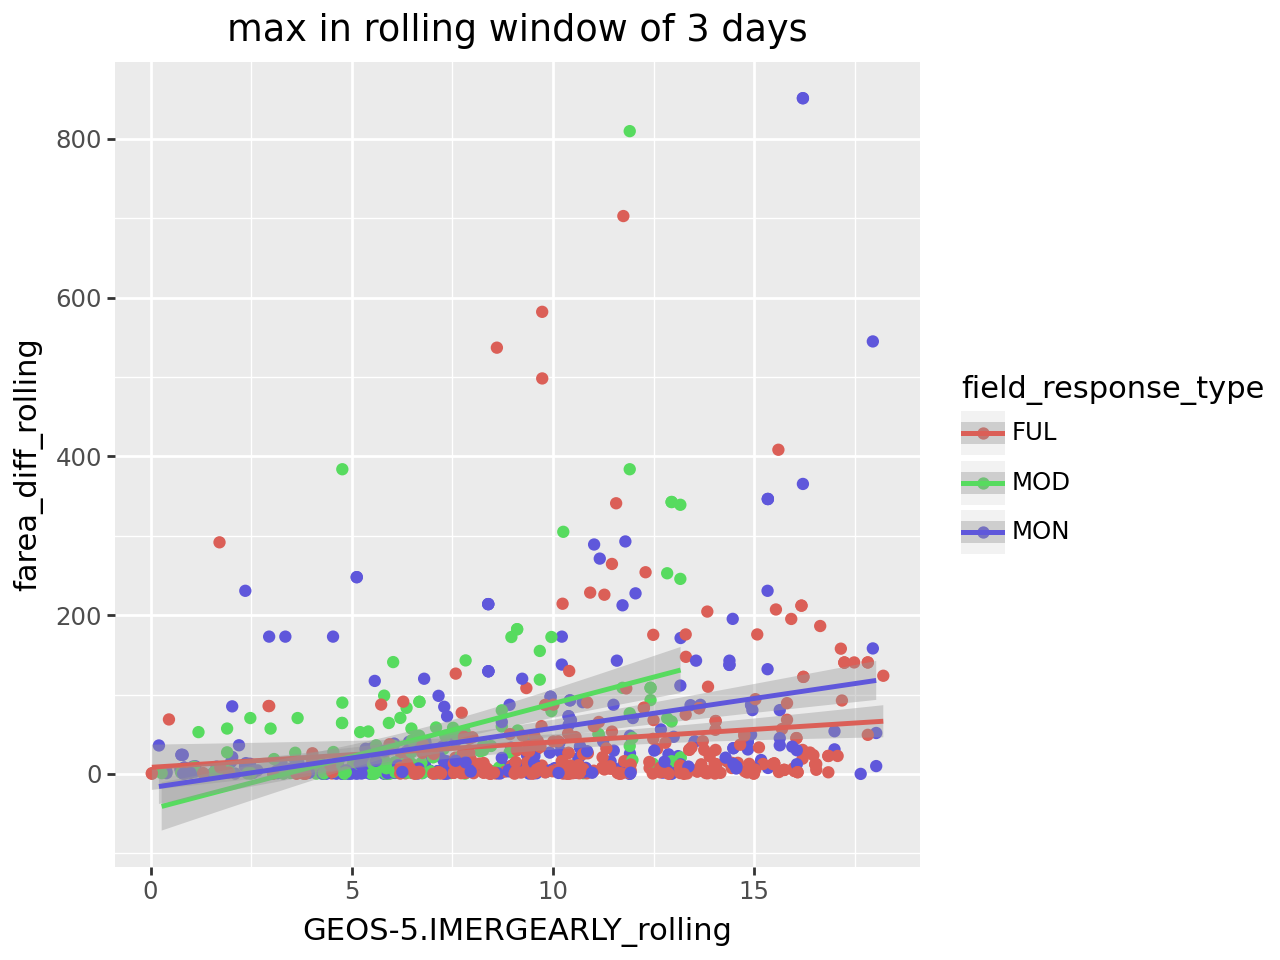

<ggplot: (640 x 480)>


In [18]:
#import numpy as np
from matplotlib import pyplot as plt
from plotnine import ggplot, geom_point, geom_jitter, aes, stat_smooth, facet_wrap
import plotnine as plotnine

### Some useful vars to color by 
def assign_day_of_fire(df):
    df = df.sort_values(by = "t")
    df['day_of_fire'] = df.t.rank()
    #df['day_of_fire'] = df['day_of_fire'].astype("int64")
    return(df)


def get_max_duration(df):
    max_duration = df.duration.max()
    df["max_duration"] = max_duration


fire3 = fire3.groupby("fireID").apply(assign_day_of_fire).reset_index(drop = True)
fire3["farea_shifted"] = fire3.groupby("fireID").farea.shift(periods = 1)

fire3["normalized_farea_diff"] = fire3.farea_diff/fire3.farea_shifted

rolling_num = 3
agg_function = "max" # max

fire3["FWI_rolling"] = fire3.groupby("fireID").FWI.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
fire3["FWI_norm_rolling"] = fire3.groupby("fireID").FWI_norm.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
fire3["FWI_diff_rolling"] = fire3.groupby("fireID").FWI_diff.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
fire3['farea_rolling'] = fire3.groupby("fireID").farea.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
fire3['farea_diff_rolling'] = fire3.groupby("fireID").farea_diff.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
fire3["GEOS-5.IMERGEARLY_rolling"] = fire3.groupby("fireID")["GEOS-5.IMERGEARLY"].rolling(rolling_num).agg(agg_function).reset_index(drop = True)

long_fires = fire3[fire3.day_of_fire > 3].fireID.unique()
#fire3['max_dof'] = fire3.groupby("fireID").day_of_fire.max()

row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)

#x_var = ["FWI","FWI_rolling", "FWI_diff_rolling", "FWI_norm_rolling"]
#y_var = ['farea', "normalized_farea_diff", 'farea_rolling', 'farea_diff_rolling']


x_var = ["FWI","FWI_rolling", "FWI_diff_rolling", "GEOS-5.IMERGEARLY", "GEOS-5.IMERGEARLY_rolling"]
y_var = [ 'farea_diff_rolling']

for x in x_var:
    for y in y_var:
        #p = (ggplot(fire3[row_mask], aes( x = x, y = y, color = 'field_latitude'))
        p = (ggplot(fire3[row_mask], aes( x = x, y = y, color = "field_response_type"))
        #p = (ggplot(fire3[row_mask], aes( x = x, y = y, color = "farea_shifted"))
         + geom_point()
         + plotnine.labels.ylab(y)
         + plotnine.labels.xlab(x)
         + stat_smooth(method = "glm", formula = "y ~ x")
         #+ plotnine.scale_y_log10()
         + plotnine.ggtitle(f"{agg_function} in rolling window of {rolling_num} days")

         )
        p.show()
        print(p)
        #del(p)


In [20]:
plt.plot(fire3[]["FWI_rolling"], fire3.t)
plt.plot()

In [21]:
fire3.fireID

0       1003
1       1003
2       1003
3       1003
4       1003
        ... 
7955     891
7956     891
7957     891
7958     891
7959     891
Name: fireID, Length: 7960, dtype: object